# 08 - Bayesian linear regression

**Goal.** Extend the normal model of chapter 06 to regression: an outcome that
depends linearly on predictors. We derive the posterior under the standard reference
prior, sample it exactly, and see that the credible intervals reproduce the classical
ones. We then build credible and prediction bands, add an informative conjugate prior
(and find ridge regression inside it), and check the model against the data with a
posterior predictive check.

## 1. The model

We observe $n$ pairs $(x_i, y_i)$ and model
$$ y_i = \beta_0 + \beta_1 x_{i1} + \dots + \beta_{p-1}x_{i,p-1} + \varepsilon_i,\qquad \varepsilon_i\overset{\text{iid}}{\sim}\text{Normal}(0,\sigma^2). $$
In matrix form, with a column of ones in the $n\times p$ design matrix $X$ for the
intercept, $y = X\beta+\varepsilon$ and
$$ p(y\mid\beta,\sigma^2) = (2\pi\sigma^2)^{-n/2}\exp\!\Big(-\frac{1}{2\sigma^2}\,\lVert y-X\beta\rVert^2\Big). $$
The unknowns are the $p$ coefficients $\beta$ and the noise variance $\sigma^2$.

**A key identity.** Let $\hat\beta = (X^\top X)^{-1}X^\top y$ be the least-squares
estimate and $\text{RSS} = \lVert y-X\hat\beta\rVert^2$ its residual sum of squares.
Writing $y-X\beta = (y-X\hat\beta) + X(\hat\beta-\beta)$ and expanding, the cross term
vanishes because the least-squares residuals are orthogonal to the columns of $X$
($X^\top(y-X\hat\beta)=0$). So
$$ \lVert y-X\beta\rVert^2 = \text{RSS} + (\beta-\hat\beta)^\top X^\top X\,(\beta-\hat\beta). $$
As a function of $\beta$, the likelihood is a multivariate normal kernel centred at
$\hat\beta$. That is what makes everything below closed form.

## 2. The reference prior and its posterior

With no strong prior information, the standard choice is flat on $\beta$ and
$1/\sigma^2$ on the variance (Jeffreys-style, chapter 07):
$$ p(\beta,\sigma^2)\propto\frac{1}{\sigma^2}. $$
It is improper, but the posterior is proper when $n>p$ and $X$ has full rank. By the
identity above,
$$ p(\beta,\sigma^2\mid y)\;\propto\;(\sigma^2)^{-n/2-1}\exp\!\Big(-\frac{\text{RSS} + (\beta-\hat\beta)^\top X^\top X(\beta-\hat\beta)}{2\sigma^2}\Big). $$
Read this in two steps, exactly as in chapter 06.

**Given $\sigma^2$**, the dependence on $\beta$ is a normal kernel:
$$ \beta\mid\sigma^2,y\sim\text{Normal}\big(\hat\beta,\ \sigma^2(X^\top X)^{-1}\big). $$
**Integrating out $\beta$** (a normal integral that contributes a factor $(\sigma^2)^{p/2}$)
leaves
$$ p(\sigma^2\mid y)\propto(\sigma^2)^{-\frac{n-p}{2}-1}e^{-\text{RSS}/(2\sigma^2)}
   \quad\Longrightarrow\quad \sigma^2\mid y\sim\text{InvGamma}\Big(\frac{n-p}{2},\ \frac{\text{RSS}}{2}\Big). $$
**Each coefficient marginally** is a $t$ with $n-p$ degrees of freedom:
$$ \beta_j\mid y\sim t_{n-p}\Big(\hat\beta_j,\ s^2\big[(X^\top X)^{-1}\big]_{jj}\Big),\qquad s^2 = \frac{\text{RSS}}{n-p}. $$
These are exactly the estimates, standard errors and $t$ intervals that classical
least squares reports. Under this prior, Bayesian and classical regression agree
numerically [1, 3]; the Bayesian version adds the probability interpretation and,
through sampling, easy answers to questions about any function of the parameters.

## 3. Example: temperature and iced drinks

A kiosk records the daily high temperature (°C) and the number of iced drinks sold
on 25 days. (The data are simulated so that the true relationship is known:
intercept 20, slope 4.5 drinks per °C, noise standard deviation 12.)

We sample the posterior exactly by **composition**, as in chapter 06: draw $\sigma^2$
from its inverse-gamma, then $\beta$ from its normal given that $\sigma^2$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (7.5, 3.4), "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})
PRIOR, LIK, POST = "#8a949e", "#eb6834", "#2a78d6"
rng = np.random.default_rng(8)

n = 25
temp = np.round(rng.uniform(12, 34, n), 1)
drinks = np.round(20 + 4.5 * temp + rng.normal(0, 12, n))
X = np.column_stack([np.ones(n), temp])
p = X.shape[1]

XtX_inv = np.linalg.inv(X.T @ X)
beta_hat = XtX_inv @ X.T @ drinks
rss = np.sum((drinks - X @ beta_hat) ** 2)
s2 = rss / (n - p)

S = 20_000
sigma2 = 1 / rng.gamma((n - p) / 2, 2 / rss, size=S)                 # InvGamma((n-p)/2, RSS/2)
L = np.linalg.cholesky(XtX_inv)
beta = beta_hat + np.sqrt(sigma2)[:, None] * (rng.standard_normal((S, p)) @ L.T)

tq = stats.t.ppf(0.975, n - p)
for j, name in enumerate(["intercept", "slope"]):
    se = np.sqrt(s2 * XtX_inv[j, j])
    lo, hi = np.quantile(beta[:, j], [0.025, 0.975])
    print(f"{name:<9}  least squares {beta_hat[j]:7.2f} ± {tq * se:5.2f} (classical 95% CI)  |  "
          f"posterior mean {beta[:, j].mean():7.2f}, 95% credible ({lo:6.2f}, {hi:6.2f})")
print(f"noise sd: s = {np.sqrt(s2):.2f}; posterior median of σ = {np.median(np.sqrt(sigma2)):.2f}")
print(f"P(slope > 4 | data) = {(beta[:, 1] > 4).mean():.3f}")

intercept  least squares   24.63 ± 23.43 (classical 95% CI)  |  posterior mean   24.66, 95% credible (  1.67,  48.34)
slope      least squares    4.16 ±  1.04 (classical 95% CI)  |  posterior mean    4.15, 95% credible (  3.09,   5.17)
noise sd: s = 14.55; posterior median of σ = 14.78
P(slope > 4 | data) = 0.620


Because we have samples, any derived quantity has a posterior for free. For example,
the temperature at which expected sales reach 150 drinks is $(150-\beta_0)/\beta_1$;
its posterior is just that formula applied to each sample.

temperature for 150 expected drinks: median 30.2 °C, 95% interval (28.0, 33.5) °C


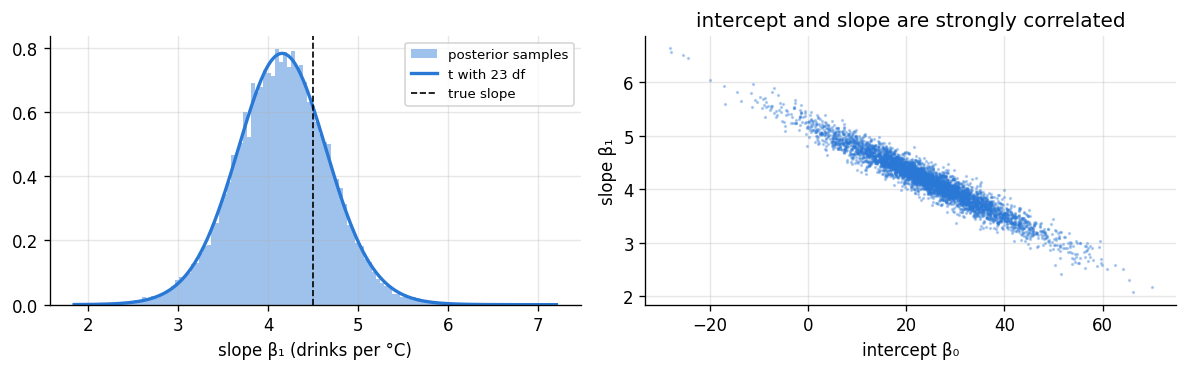

In [2]:
t150 = (150 - beta[:, 0]) / beta[:, 1]
print(f"temperature for 150 expected drinks: median {np.median(t150):.1f} °C, "
      f"95% interval ({np.quantile(t150, 0.025):.1f}, {np.quantile(t150, 0.975):.1f}) °C")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].hist(beta[:, 1], bins=120, density=True, color=POST, alpha=0.45, label="posterior samples")
g = np.linspace(beta[:, 1].min(), beta[:, 1].max(), 300)
ax[0].plot(g, stats.t.pdf(g, n - p, beta_hat[1], np.sqrt(s2 * XtX_inv[1, 1])), color=POST, lw=2,
           label=f"t with {n - p} df")
ax[0].axvline(4.5, color="k", ls="--", lw=1, label="true slope")
ax[0].set_xlabel("slope β₁ (drinks per °C)"); ax[0].legend(fontsize=8)
ax[1].plot(beta[:4000, 0], beta[:4000, 1], ".", ms=2, alpha=0.3, color=POST)
ax[1].set_xlabel("intercept β₀"); ax[1].set_ylabel("slope β₁")
ax[1].set_title("intercept and slope are strongly correlated")
plt.tight_layout(); plt.show()

The strong negative correlation between intercept and slope happens because the
temperatures are all far from zero: a line through the cloud of points can pivot, and
a steeper line needs a lower intercept. Centring the predictor (using
$x-\bar x$) removes it, which is worth doing in practice.

## 4. Credible bands and prediction bands

Two different questions about a new temperature $\tilde x$:

- **What are expected sales at $\tilde x$?** The mean $\tilde x^\top\beta$ is uncertain
  only because $\beta$ is. Its posterior gives a **credible band** for the regression line.
- **How many drinks will be sold on a particular day at $\tilde x$?** That adds the
  day-to-day noise: $\tilde y = \tilde x^\top\beta + \varepsilon$. Its posterior predictive
  distribution gives a much wider **prediction band**. Analytically it is
  $t_{n-p}\big(\tilde x^\top\hat\beta,\ s^2(1+\tilde x^\top(X^\top X)^{-1}\tilde x)\big)$;
  by simulation it is one extra line: add a normal draw with each sample's own $\sigma$.

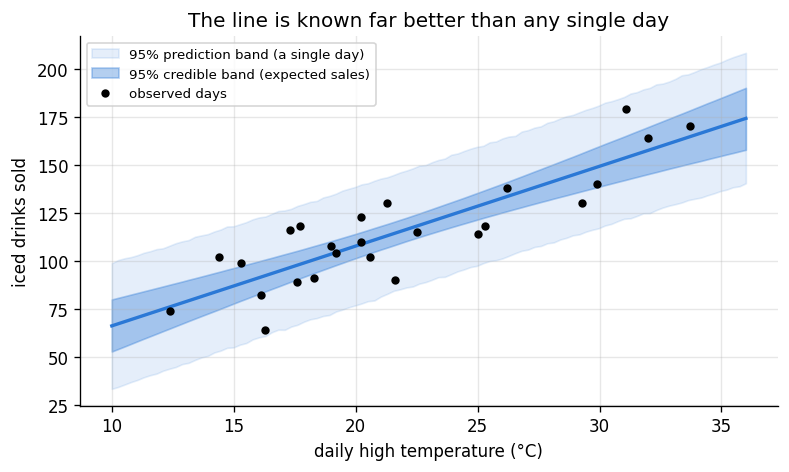

share of observed days inside the 95% prediction band: 1.00


In [3]:
xg = np.linspace(10, 36, 100)
Xg = np.column_stack([np.ones_like(xg), xg])
mean_draws = beta @ Xg.T                                                   # S x 100
pred_draws = mean_draws + rng.normal(0, 1, mean_draws.shape) * np.sqrt(sigma2)[:, None]

plt.figure(figsize=(7.5, 4))
plt.fill_between(xg, *np.quantile(pred_draws, [0.025, 0.975], axis=0), color=POST, alpha=0.12,
                 label="95% prediction band (a single day)")
plt.fill_between(xg, *np.quantile(mean_draws, [0.025, 0.975], axis=0), color=POST, alpha=0.35,
                 label="95% credible band (expected sales)")
plt.plot(xg, Xg @ beta_hat, color=POST, lw=2)
plt.plot(temp, drinks, "o", color="k", ms=4, label="observed days")
inside = np.mean((drinks >= np.quantile(pred_draws, 0.025, axis=0)[np.searchsorted(xg, temp)]) &
                 (drinks <= np.quantile(pred_draws, 0.975, axis=0)[np.searchsorted(xg, temp)]))
plt.xlabel("daily high temperature (°C)"); plt.ylabel("iced drinks sold")
plt.title("The line is known far better than any single day")
plt.legend(fontsize=8, loc="upper left"); plt.show()
print(f"share of observed days inside the 95% prediction band: {inside:.2f}")

## 5. An informative conjugate prior, and ridge regression

When prior information exists, the conjugate prior is the normal-inverse-gamma of
chapter 06, now for a vector:
$$ \beta\mid\sigma^2\sim\text{Normal}(m_0,\ \sigma^2V_0),\qquad \sigma^2\sim\text{InvGamma}(a_0,b_0). $$
Completing the square in $\beta$ once more gives [2, 4]
$$ V_n = (V_0^{-1}+X^\top X)^{-1},\qquad m_n = V_n\,(V_0^{-1}m_0 + X^\top y), $$
$$ a_n = a_0+\frac n2,\qquad b_n = b_0 + \frac12\big(y^\top y + m_0^\top V_0^{-1}m_0 - m_n^\top V_n^{-1}m_n\big), $$
with $\beta\mid\sigma^2,y\sim$ Normal$(m_n,\sigma^2V_n)$ and $\sigma^2\mid y\sim$ InvGamma$(a_n,b_n)$.
Precisions add again: $V_n^{-1} = V_0^{-1}+X^\top X$. The posterior mean combines the
prior mean and the data, each weighted by its precision.

**Ridge regression is a posterior mean.** Take $m_0 = 0$ and $V_0 = \frac1\lambda I$
(for the slopes; the intercept is usually left unpenalised by centring). Then
$m_n = (X^\top X+\lambda I)^{-1}X^\top y$, which is exactly the ridge estimator [5].
The ridge penalty $\lambda$ is a prior belief that coefficients are small, and a
larger $\lambda$ is a more confident prior. The plot shows the posterior mean slope
as the prior on the slope tightens around zero, for the full data and for only the
first 5 days.

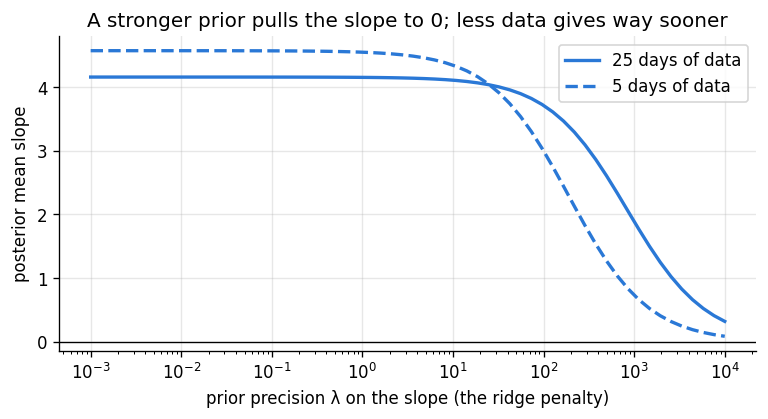

In [4]:
xc = temp - temp.mean()                           # centre, so the intercept prior can stay vague
def posterior_slope(lam, k):
    Xk = np.column_stack([np.ones(k), xc[:k]])
    V0_inv = np.diag([1e-8, lam])                 # almost flat on the intercept, precision lam on the slope
    Vn = np.linalg.inv(V0_inv + Xk.T @ Xk)
    return (Vn @ Xk.T @ drinks[:k])[1]

lams = np.logspace(-3, 4, 60)
for k, style in [(n, "-"), (5, "--")]:
    plt.plot(lams, [posterior_slope(l, k) for l in lams], style, color=POST, lw=2, label=f"{k} days of data")
plt.xscale("log"); plt.axhline(0, color="k", lw=0.8)
plt.xlabel("prior precision λ on the slope (the ridge penalty)"); plt.ylabel("posterior mean slope")
plt.title("A stronger prior pulls the slope to 0; less data gives way sooner")
plt.legend(); plt.show()

## 6. Checking the model: posterior predictive checks

A posterior is only as good as the model behind it. A **posterior predictive check**
asks: if the model were right, would data like ours be typical [6]? Simulate
replicated datasets $y^{\text{rep}}$ from the posterior predictive at the observed
$x$ values, compute a test statistic $T$ on each, and see where $T(y)$ for the real
data falls. A value in the extreme tail signals a feature of the data the model
cannot reproduce.

Here we use two statistics: the largest absolute residual from the least-squares
line (sensitive to outliers) and the correlation between residuals and temperature
squared (sensitive to curvature the straight line misses).

In [5]:
def T(yv):
    b = np.linalg.lstsq(X, yv, rcond=None)[0]
    r = yv - X @ b
    return np.abs(r).max(), np.corrcoef(r, temp**2)[0, 1]

reps = X @ beta[:2000].T + rng.normal(0, 1, (n, 2000)) * np.sqrt(sigma2[:2000])
T_rep = np.array([T(reps[:, s]) for s in range(2000)])
T_obs = T(drinks)
for j, name in enumerate(["max |residual|", "corr(residual, temp²)"]):
    print(f"{name:<22} observed {T_obs[j]:7.3f}; share of replicates at least as large: {(T_rep[:, j] >= T_obs[j]).mean():.2f}")

max |residual|         observed  28.362; share of replicates at least as large: 0.66
corr(residual, temp²)  observed   0.026; share of replicates at least as large: 0.15


Neither observed statistic is extreme, so these checks find nothing the model gets
wrong, as they should for data that really came from this model. Exercise 5 shows
what happens when the model is wrong.

### Exercises

1. Show that the cross term in $\lVert y-X\beta\rVert^2$ vanishes, using the normal
   equations $X^\top X\hat\beta = X^\top y$.
2. Centre the temperature and refit. What happens to the posterior correlation between
   intercept and slope, and to the interpretation of the intercept?
3. Using the samples, compute the posterior probability that a 30 °C day sells more than
   170 drinks. Compare with the analytic $t$ predictive distribution.
4. Use the informative prior with $m_0 = (0, 5)$, $V_0 = \mathrm{diag}(10^6, 0.1)$,
   $a_0 = 2$, $b_0 = 200$ on the first 5 days only. How much does it help compared with
   the reference prior on the same 5 days?
5. Generate data with a curved relationship (add $0.3\,(x-23)^2$ to the mean) and rerun
   the posterior predictive check. Which statistic detects the problem?

## References

1. G. E. P. Box, G. C. Tiao. *Bayesian Inference in Statistical Analysis.* Addison-Wesley, 1973. (Chapter 2.)
2. A. Zellner. *An Introduction to Bayesian Inference in Econometrics.* Wiley, 1971.
3. A. Gelman et al. *Bayesian Data Analysis*, 3rd ed. CRC Press, 2013. (Chapter 14.)
4. D. V. Lindley, A. F. M. Smith. *Bayes estimates for the linear model.* Journal of the Royal Statistical Society B, 34(1):1-41, 1972.
5. A. E. Hoerl, R. W. Kennard. *Ridge regression: biased estimation for nonorthogonal problems.* Technometrics, 12(1):55-67, 1970. doi:10.1080/00401706.1970.10488634
6. D. B. Rubin. *Bayesianly justifiable and relevant frequency calculations for the applied statistician.* The Annals of Statistics, 12(4):1151-1172, 1984. doi:10.1214/aos/1176346785
7. A. Gelman, X.-L. Meng, H. Stern. *Posterior predictive assessment of model fitness via realized discrepancies.* Statistica Sinica, 6(4):733-760, 1996.
8. P. D. Hoff. *A First Course in Bayesian Statistical Methods.* Springer, 2009. (Chapter 9.)